# BrechApp - Final Analysis

This notebook performs the comprehensive analysis required by the BrechApp project, including:
1.  **Gap Calculation**: Brecha between Blue/MEP/CCL and Official.
2.  **Moving Averages**: 7-day and 30-day trends.
3.  **Volatility**: Rolling standard deviation.
4.  **Distribution**: Histograms of daily variations.

**Technology Stack**: Polars (Processing), Seaborn/Matplotlib (Visualization).

In [32]:
import polars as pl
import seaborn as sns
import matplotlib.pyplot as plt
import os

# Configuration
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (14, 7)

# Load Data
processed_dir = os.path.join('..', 'data', 'processed')
parquet_path = os.path.join(processed_dir, 'history.parquet')

if not os.path.exists(parquet_path):
    print(f"Error: {parquet_path} not found. Please run src/processing/process_history.py first.")
else:
    df = pl.read_parquet(parquet_path)
    print(f"Loaded {df.height} records.")
    print(df.head())

Loaded 20742 records.
shape: (5, 4)
┌──────┬────────┬───────┬────────────┐
│ casa ┆ compra ┆ venta ┆ fecha      │
│ ---  ┆ ---    ┆ ---   ┆ ---        │
│ str  ┆ f64    ┆ f64   ┆ date       │
╞══════╪════════╪═══════╪════════════╡
│ blue ┆ 4.0    ┆ 4.0   ┆ 2011-01-03 │
│ blue ┆ 4.0    ┆ 4.0   ┆ 2011-01-04 │
│ blue ┆ 4.0    ┆ 4.0   ┆ 2011-01-05 │
│ blue ┆ 4.0    ┆ 4.0   ┆ 2011-01-06 │
│ blue ┆ 4.0    ┆ 4.0   ┆ 2011-01-07 │
└──────┴────────┴───────┴────────────┘


## 1. Data Preparation & Gap Calculation

In [33]:
# Pivot data to wide format (one column per dollar type)
df_wide = df.pivot(
    values="venta",
    index="fecha",
    columns="casa",
    aggregate_function="first"
).sort("fecha")

# Calculate Gaps (Brechas)
# Brecha = ((Parallel - Official) / Official) * 100
if "oficial" in df_wide.columns:
    for col in ["blue", "mep", "contadoconliqui"]:
        if col in df_wide.columns:
            df_wide = df_wide.with_columns(
                ((pl.col(col) - pl.col("oficial")) / pl.col("oficial") * 100).alias(f"brecha_{col}")
            )

df_wide.tail()

C:\Users\davos\AppData\Local\Temp\ipykernel_24472\3837989801.py:2: DeprecationWarning: the argument `columns` for `DataFrame.pivot` is deprecated. It was renamed to `on` in version 1.0.0.
  df_wide = df.pivot(


fecha,blue,contadoconliqui,mayorista,oficial,brecha_blue,brecha_contadoconliqui
date,f64,f64,f64,f64,f64,f64
2025-11-25,1460.0,1525.1,1447.5,1470.0,-0.680272,3.748299
2025-11-26,1450.0,1531.3,1453.5,1475.0,-1.694915,3.816949
2025-11-27,1440.0,1531.3,1450.0,1475.0,-2.372881,3.816949
2025-11-28,1435.0,1516.1,1451.5,1475.0,-2.711864,2.786441
2025-11-29,1435.0,1516.1,1451.5,1475.0,-2.711864,2.786441


## 2. Time Series Analysis: Evolution of the Gap

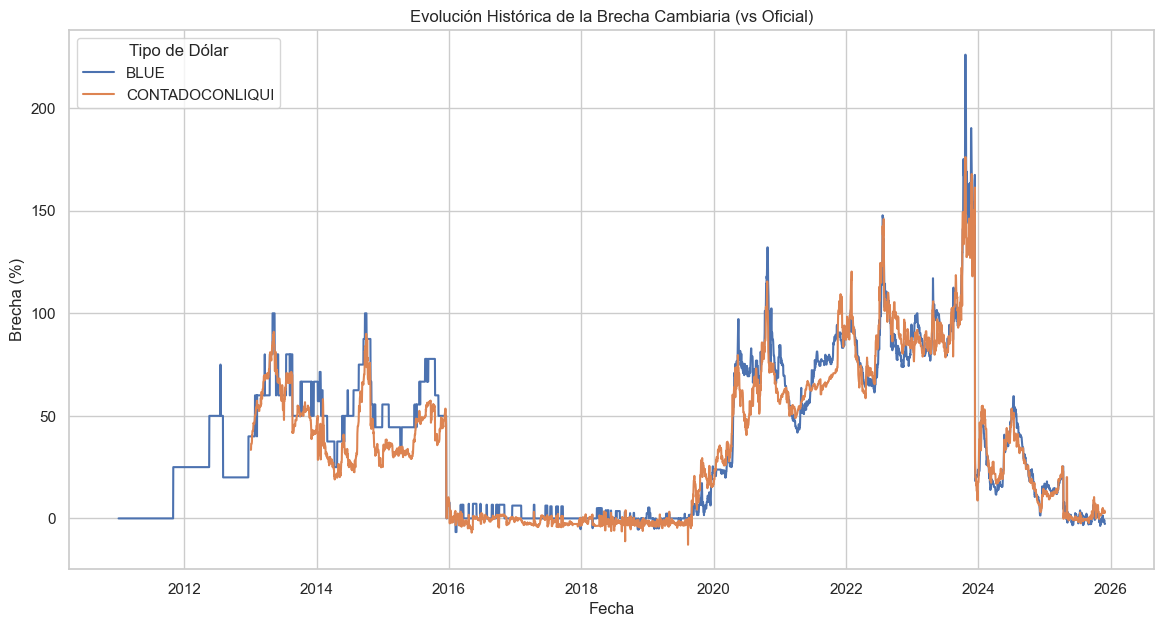

In [34]:
# Convert to Pandas for plotting
pdf = df_wide.to_pandas()

plt.figure(figsize=(14, 7))
for col in ["brecha_blue", "brecha_mep", "brecha_contadoconliqui"]:
    if col in pdf.columns:
        sns.lineplot(data=pdf, x="fecha", y=col, label=col.replace("brecha_", "").upper())

plt.title("Evolución Histórica de la Brecha Cambiaria (vs Oficial)")
plt.ylabel("Brecha (%)")
plt.xlabel("Fecha")
plt.legend(title="Tipo de Dólar")
plt.savefig('brecha_cambiaria.png', bbox_inches='tight')
plt.show()



## 3. Moving Averages (Tendencias)

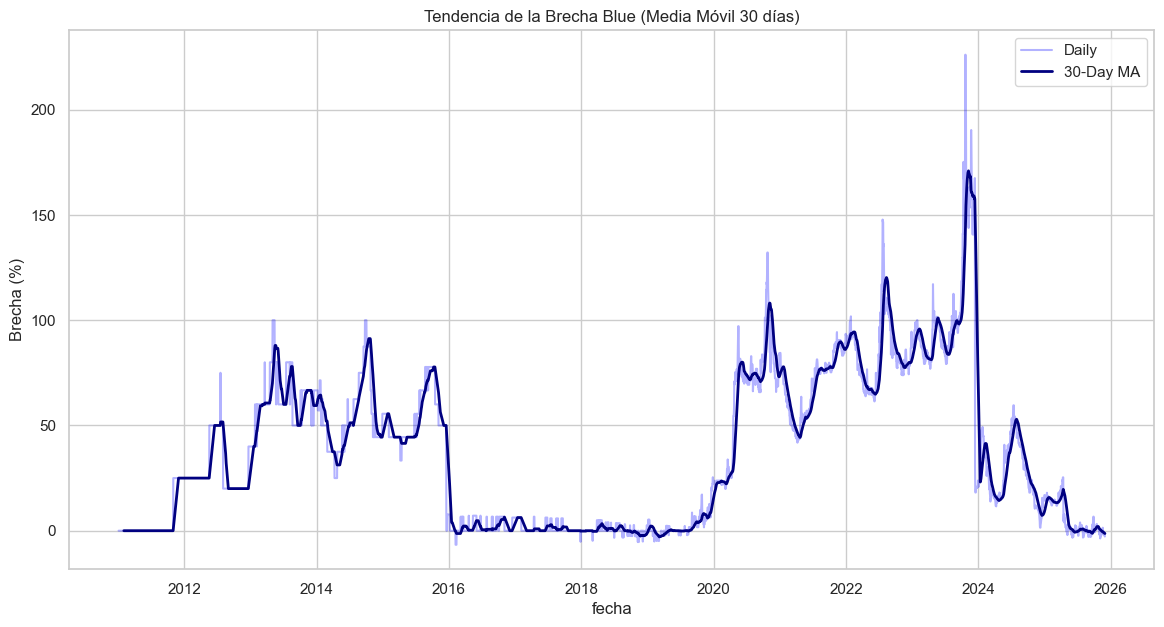

In [35]:
# Calculate 30-day Moving Average for Blue Gap
if "brecha_blue" in df_wide.columns:
    df_wide = df_wide.with_columns(
        pl.col("brecha_blue").rolling_mean(window_size=30).alias("brecha_blue_ma30")
    )
    
    # Plot
    pdf = df_wide.select(["fecha", "brecha_blue", "brecha_blue_ma30"]).to_pandas()
    
    plt.figure(figsize=(14, 7))
    sns.lineplot(data=pdf, x="fecha", y="brecha_blue", alpha=0.3, label="Daily", color="blue")
    sns.lineplot(data=pdf, x="fecha", y="brecha_blue_ma30", linewidth=2, label="30-Day MA", color="navy")
    plt.title("Tendencia de la Brecha Blue (Media Móvil 30 días)")
    plt.ylabel("Brecha (%)")
    plt.savefig('brecha_blue_ma30.png', bbox_inches='tight')
    plt.show()
    


## 4. Volatility Analysis
We calculate the 30-day rolling standard deviation of the daily percentage change of the Blue dollar.

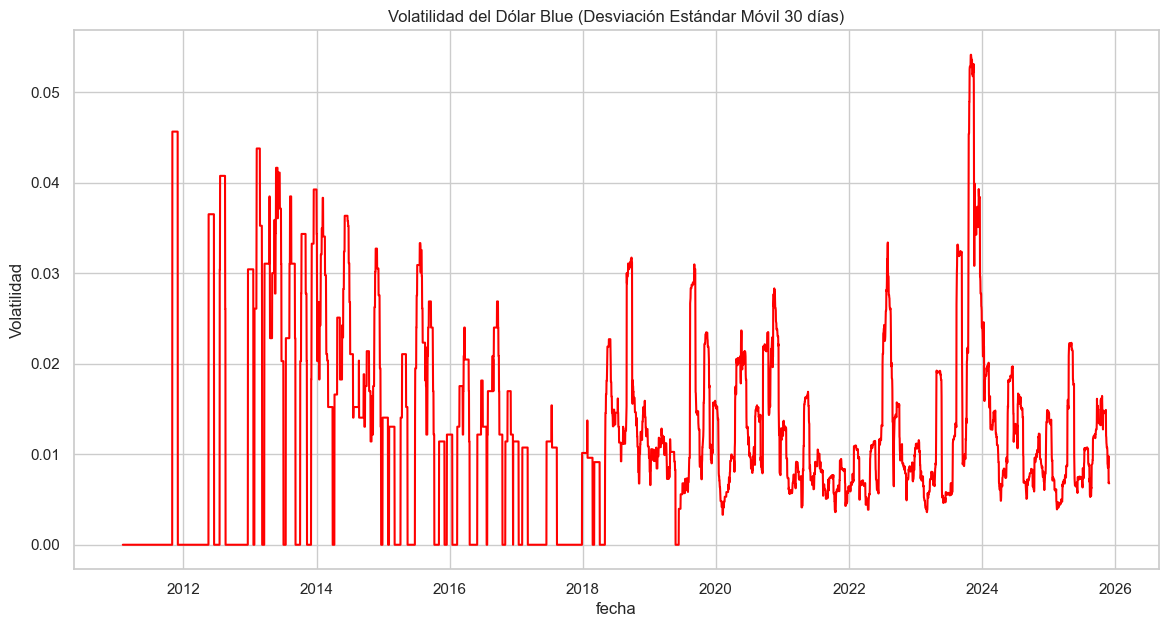

In [36]:
if "blue" in df_wide.columns:
    # Calculate daily returns first
    df_vol = df_wide.with_columns(
        pl.col("blue").pct_change().alias("blue_daily_return")
    )
    
    # Calculate rolling std dev (volatility)
    df_vol = df_vol.with_columns(
        pl.col("blue_daily_return").rolling_std(window_size=30).alias("blue_volatility_30d")
    )
    
    # Plot
    pdf_vol = df_vol.select(["fecha", "blue_volatility_30d"]).drop_nulls().to_pandas()
    
    plt.figure(figsize=(14, 7))
    sns.lineplot(data=pdf_vol, x="fecha", y="blue_volatility_30d", color="red")
    plt.title("Volatilidad del Dólar Blue (Desviación Estándar Móvil 30 días)")
    plt.ylabel("Volatilidad")
    plt.savefig('blue_volatility_30d.png', bbox_inches='tight')
    plt.show()
    


## 5. Distribution of Daily Variations (Histograms)

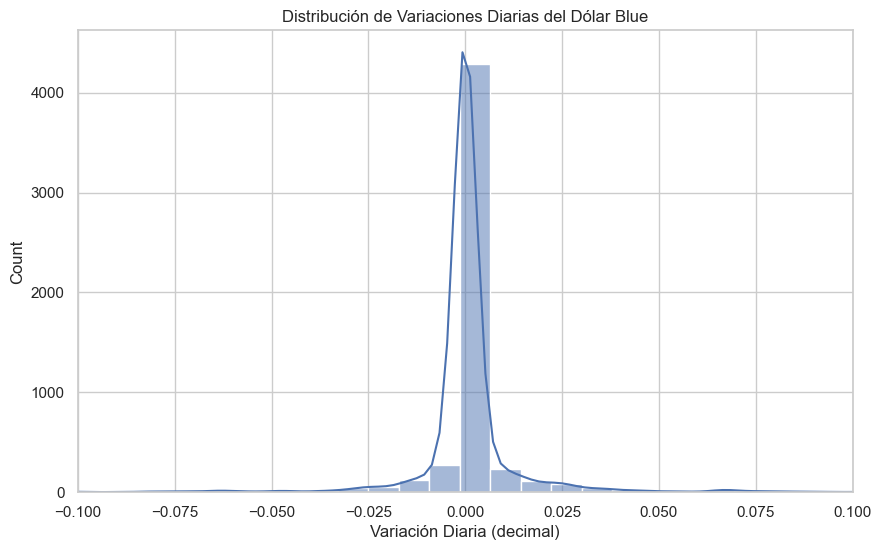

In [37]:
if "blue_daily_return" in df_vol.columns:
    pdf_hist = df_vol.select("blue_daily_return").drop_nulls().to_pandas()
    
    plt.figure(figsize=(10, 6))
    sns.histplot(data=pdf_hist, x="blue_daily_return", bins=50, kde=True)
    plt.title("Distribución de Variaciones Diarias del Dólar Blue")
    plt.xlabel("Variación Diaria (decimal)")
    plt.xlim(-0.1, 0.1) # Limit x-axis to remove extreme outliers for better visibility
    plt.savefig('blue_daily_return.png', bbox_inches='tight')
    plt.show()
    
